# Model 2: Seq2Seq with Luong Attention (Luong Dot Attention)

**Purpose:**  
Implement a sequence-to-sequence LSTM model **with Luong Attention** for the WikiQA chatbot.  
This is the second model for the group project.

**What this notebook does:**
1. Loads pre-processed data from `correct-answers-only`
2. Builds Encoder + Luong Attention Decoder
3. Trains the model
4. Evaluates with BLEU score + sample outputs
5. Compares with Model 1 (no attention)


## Section 1: Imports and Configuration

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import json
from pathlib import Path
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import random

PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

# Sutskever et al. (2014): 1000-dim embeddings matched to 1000-dim hidden units;
# equal embedding and hidden dimensions is the standard convention in basic
# encoder-decoder implementations.
EMBED_DIM = 128
# With only ~700 training pairs the model is severely over-parameterised at
# 256 hidden units. Reducing to 128 lowers capacity and narrows the
# bias-variance gap. Geman et al. (1992), Neural Computation.
HIDDEN_DIM = 128
# Sutskever et al. (2014) use 4 layers on 12M+ WMT sentence pairs and report
# ~10% perplexity reduction per additional layer. On the present dataset of
# fewer than 1 000 pairs, a single layer is preferred to minimise overfitting.
N_LAYERS = 1
# Srivastava et al. (2014): 'p can simply be set at 0.5, which seems to be
# close to optimal for a wide range of networks and tasks'.
DROPOUT = 0.5
# Keskar et al. (2017): small batches converge to flat minima, improving
# generalisation; large batches converge to sharp minima with poorer
# generalisation.
BATCH_SIZE = 32
# Williams and Zipser (1989): teacher forcing feeds ground-truth tokens as
# decoder input, stabilising early training by preventing compounding decoder
# errors. A fixed ratio of 0.7 is a common starting point. Bengio et al.
# (2015) propose scheduled sampling to gradually reduce this ratio during
# training to close the exposure-bias gap between training and inference.
TEACHER_FORCING_RATIO = 0.7
# Kingma and Ba (2015): default alpha=0.001; halved for small-dataset stability.
LEARNING_RATE = 5e-4
# Pascanu, Mikolov and Bengio (2013): norm clipping prevents exploding
# gradients in RNNs; threshold is insensitive over a wide range.
CLIP = 1.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## Section 2: Encoder

Same Encoder as Model 1. Converts the input question into hidden states.

In [9]:
class Encoder(nn.Module):
    """
    LSTM encoder that maps question tokens to hidden states.
    Stores embedding and LSTM layers for sequence encoding.
    Provides forward() to return encoder outputs and final hidden state.
    """

    def __init__(self, vocabSize, embedDim, hiddenDim, numLayers, dropoutRate):
        """
        Initializes encoder layers.
        @param vocabSize Size of vocabulary.
        @param embedDim Embedding dimension.
        @param hiddenDim Hidden state dimension.
        @param numLayers Number of LSTM layers.
        @param dropoutRate Dropout probability.
        """
        super().__init__()
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedDim,
            hiddenDim,
            numLayers,
            batch_first=True,
            dropout=dropoutRate if numLayers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropoutRate)

    def forward(self, src, srcLens):
        """
        Encodes a batch of padded token sequences.
        @param src Padded token indices with shape (batch, seq).
        @param srcLens Lengths of each sequence in src.
        @return Tuple of (encoderOutputs, hiddenState).
        """
        embedded = self.dropout(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, srcLens.cpu(), batch_first=True, enforce_sorted=False
        )
        packedOutput, hiddenState = self.lstm(packed)
        encoderOutputs, _ = nn.utils.rnn.pad_packed_sequence(
            packedOutput, batch_first=True
        )
        return encoderOutputs, hiddenState

## Section 3: Luong Attention Decoder (Model 2 Core)

At every decoding step, it uses **Luong Dot Attention** to focus on the most relevant words in the question.

In [10]:
class LuongAttnDecoder(nn.Module):
    """
    Luong dot-product attention decoder for Seq2Seq.
    Stores embedding, LSTM, attention projection, and output layers.
    Provides forward() to decode one step with attention context.
    """

    def __init__(self, vocabSize, embedDim, hiddenDim, numLayers, dropoutRate):
        """
        Initializes decoder layers.
        @param vocabSize Size of vocabulary.
        @param embedDim Embedding dimension.
        @param hiddenDim Hidden state dimension.
        @param numLayers Number of LSTM layers.
        @param dropoutRate Dropout probability.
        """
        super().__init__()
        self.hiddenDim = hiddenDim
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedDim,
            hiddenDim,
            numLayers,
            batch_first=True,
            dropout=dropoutRate if numLayers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropoutRate)

        self.concat = nn.Linear(hiddenDim * 2, hiddenDim)
        self.fc = nn.Linear(hiddenDim, vocabSize)

    def forward(self, token, hiddenState, encoderOutputs):
        """
        Decodes one token with Luong attention.
        @param token Current token ids with shape (batch,).
        @param hiddenState Previous LSTM hidden state tuple.
        @param encoderOutputs Encoder outputs for attention.
        @return Tuple of (logits, nextHiddenState).
        """
        embedded = self.dropout(self.embedding(token.unsqueeze(1)))
        output, nextHidden = self.lstm(embedded, hiddenState)

        attnWeights = torch.bmm(output, encoderOutputs.transpose(1, 2))
        attnWeights = F.softmax(attnWeights, dim=-1)
        context = torch.bmm(attnWeights, encoderOutputs)

        concatInput = torch.cat((output, context), dim=2)
        concatOutput = torch.tanh(self.concat(concatInput))
        logits = self.fc(concatOutput.squeeze(1))
        return logits, nextHidden

## Section 4: Complete Seq2Seq Model

Combines the Encoder and Luong Attention Decoder into one model.

In [11]:
class Seq2Seq(nn.Module):
    """
    Encoder-decoder wrapper for training and inference.
    Stores encoder and decoder modules for sequence modeling.
    Provides forward() for teacher-forced decoding.
    """

    def __init__(self, encoder, decoder):
        """
        Initializes the Seq2Seq wrapper.
        @param encoder Encoder module.
        @param decoder Decoder module.
        """
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, srcLens, tgt, teacherForcingRatio=0.5):
        """
        Runs a forward pass with optional teacher forcing.
        @param src Padded source token ids.
        @param srcLens Source sequence lengths.
        @param tgt Padded target token ids.
        @param teacherForcingRatio Probability of teacher forcing.
        @return Tensor of decoder logits for each time step.
        """
        batchSize, maxLen = tgt.shape
        vocabSize = self.decoder.fc.out_features

        encoderOutputs, hiddenState = self.encoder(src, srcLens)

        outputs = torch.zeros(batchSize, maxLen, vocabSize, device=DEVICE)
        token = tgt[:, 0]

        for step in range(1, maxLen):
            logits, hiddenState = self.decoder(token, hiddenState, encoderOutputs)
            outputs[:, step] = logits
            teacherForce = random.random() < teacherForcingRatio
            token = tgt[:, step] if teacherForce else logits.argmax(dim=1)

        return outputs

## Section 5: Data Loading

Loads the pre-processed data generated by `01_preprocessing.ipynb`.

In [12]:
PROCESSED_DIR = Path("../../data/processed")

with open(PROCESSED_DIR / "token2idx.json") as fileHandle:
    tokenToIdx = json.load(fileHandle)
idxToToken = {v: k for k, v in tokenToIdx.items()}

with open(PROCESSED_DIR / "train.json") as fileHandle:
    trainDf = pd.DataFrame(json.load(fileHandle))
with open(PROCESSED_DIR / "dev.json") as fileHandle:
    devDf = pd.DataFrame(json.load(fileHandle))
with open(PROCESSED_DIR / "test.json") as fileHandle:
    testDf = pd.DataFrame(json.load(fileHandle))


class WikiQADataset(Dataset):
    """
    Dataset wrapper for WikiQA token id pairs.
    Stores question and answer id sequences for indexing.
    Provides __len__ and __getitem__ for DataLoader use.
    """

    def __init__(self, dataFrame):
        """
        Stores question and answer id lists.
        @param dataFrame DataFrame with q_ids and a_ids columns.
        """
        self.qIds = dataFrame["q_ids"].tolist()
        self.aIds = dataFrame["a_ids"].tolist()

    def __len__(self):
        """
        Returns dataset size.
        @return Number of samples in dataset.
        """
        return len(self.qIds)

    def __getitem__(self, index):
        """
        Gets one sample pair as tensors.
        @param index Sample index.
        @return Tuple of (questionIds, answerIds) tensors.
        """
        return torch.tensor(self.qIds[index]), torch.tensor(self.aIds[index])


def collateBatch(batch):
    """
    Pads a batch of variable-length sequences.
    @param batch List of (questionIds, answerIds) tensors.
    @return Dict with padded src, tgt, and srcLens.
    """
    questions, answers = zip(*batch)
    src = pad_sequence(questions, batch_first=True, padding_value=PAD_IDX)
    tgt = pad_sequence(answers, batch_first=True, padding_value=PAD_IDX)
    return {
        "src": src,
        "tgt": tgt,
        "srcLens": torch.tensor([len(q) for q in questions]),
    }


trainLoader = DataLoader(
    WikiQADataset(trainDf),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collateBatch,
 )
devLoader = DataLoader(
    WikiQADataset(devDf),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collateBatch,
 )
testLoader = DataLoader(
    WikiQADataset(testDf),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collateBatch,
 )

print(f"Data loaded! Train samples: {len(trainLoader.dataset)}")

Data loaded! Train samples: 728


## Section 6: Training
## Training Helper Function (trainEpoch)

In [13]:
def trainEpoch(model, loader, optimizer, criterion):
    """
    Runs one training epoch.
    @param model Seq2Seq model to train.
    @param loader DataLoader for training data.
    @param optimizer Optimizer for model parameters.
    @param criterion Loss function.
    @return Average loss across the epoch.
    """
    model.train()
    totalLoss = 0.0

    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        srcLens = batch["srcLens"]

        optimizer.zero_grad()

        output = model(src, srcLens, tgt, TEACHER_FORCING_RATIO)

        loss = criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()

        totalLoss += loss.item()

    return totalLoss / len(loader)


@torch.no_grad()
def evaluateEpoch(model, loader, criterion):
    """
    Runs one evaluation epoch without updating weights.
    @param model Seq2Seq model to evaluate.
    @param loader DataLoader for validation data.
    @param criterion Loss function.
    @return Average loss across the epoch.
    """
    model.eval()
    totalLoss = 0.0
    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        srcLens = batch["srcLens"]
        output = model(src, srcLens, tgt, teacherForcingRatio=0.0)
        totalLoss += criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        ).item()
    return totalLoss / len(loader)

## Section 6.1: Training

Trains Model 2 using the same training loop style as Model 1.

In [14]:
import time
import math

# =====================================================
# Training Configuration
# =====================================================
# Extended ceiling; early stopping will terminate well before this if
# validation loss stops improving.
EPOCHS = 50
PATIENCE = 5

# Create the models folder if missing.
CHECKPOINT_PATH = Path("../../models/model2_luong_best.pt")
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Create Model 2
encoder = Encoder(len(tokenToIdx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = LuongAttnDecoder(len(tokenToIdx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model2 = Seq2Seq(encoder, decoder).to(DEVICE)

# Szegedy et al. (2016): label smoothing (eps=0.1) discourages overconfident
# predictions on a small training set where surface co-occurrences overfit quickly.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
# Krogh and Hertz (1992): L2 weight decay (weight_decay=1e-4) is a
# complementary regulariser to dropout that penalises large weights.
optimizer = torch.optim.Adam(model2.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
# Smith (2018): reducing the learning rate on validation plateau allows the
# optimiser to refine rather than continue overshooting on a stagnant loss
# landscape. Factor 0.5, patience 2 epochs, minimum lr 1e-5.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-5
)

trainLosses, valLosses = [], []
bestValLoss = float("inf")
epochsNoImprove = 0

print("🚀 Starting training of Model 2 (Luong Attention)...\n")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    trainLoss = trainEpoch(model2, trainLoader, optimizer, criterion)
    valLoss = evaluateEpoch(model2, devLoader, criterion)
    scheduler.step(valLoss)

    elapsed = time.time() - t0

    trainLosses.append(trainLoss)
    valLosses.append(valLoss)

    marker = ""
    if valLoss < bestValLoss:
        bestValLoss = valLoss
        epochsNoImprove = 0
        torch.save(
            {
                "model_state": model2.state_dict(),
                "token2idx": tokenToIdx,
                "embed_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM,
                "n_layers": N_LAYERS,
                "dropout": DROPOUT,
            },
            CHECKPOINT_PATH,
        )
        marker = "  ✓ best model saved"
    else:
        epochsNoImprove += 1
        if epochsNoImprove >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)"
            )
            break

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {trainLoss:.4f} (ppl {math.exp(trainLoss):6.2f}) | "
        f"val loss {valLoss:.4f} (ppl {math.exp(valLoss):6.2f}) | "
        f"{elapsed:.1f}s{marker}"
    )

print(f"\n✅ Training finished! Best val loss: {bestValLoss:.4f}")
print(f"Best model saved at: {CHECKPOINT_PATH}")

🚀 Starting training of Model 2 (Luong Attention)...

Epoch 01/50 | train loss 8.7819 (ppl 6514.94) | val loss 8.5325 (ppl 5077.34) | 1.9s  ✓ best model saved
Epoch 02/50 | train loss 7.8677 (ppl 2611.68) | val loss 7.6773 (ppl 2158.80) | 1.9s  ✓ best model saved
Epoch 03/50 | train loss 7.1718 (ppl 1302.23) | val loss 7.6378 (ppl 2075.22) | 1.8s  ✓ best model saved
Epoch 04/50 | train loss 7.1176 (ppl 1233.55) | val loss 7.5951 (ppl 1988.40) | 1.7s  ✓ best model saved
Epoch 05/50 | train loss 7.0980 (ppl 1209.49) | val loss 7.5882 (ppl 1974.84) | 1.7s  ✓ best model saved
Epoch 06/50 | train loss 7.0818 (ppl 1190.08) | val loss 7.5862 (ppl 1970.81) | 1.7s  ✓ best model saved
Epoch 07/50 | train loss 7.0632 (ppl 1168.17) | val loss 7.5784 (ppl 1955.44) | 1.7s  ✓ best model saved
Epoch 08/50 | train loss 7.0504 (ppl 1153.36) | val loss 7.5777 (ppl 1954.13) | 1.7s  ✓ best model saved
Epoch 09/50 | train loss 7.0348 (ppl 1135.44) | val loss 7.5782 (ppl 1955.02) | 1.7s
Epoch 10/50 | train lo

## Section 7: Evaluation (BLEU Score + Sample Outputs)
Calculates BLEU-1 score and shows sample predictions with comparison to real answers.

In [15]:
# =====================================================
# SECTION 7: Evaluation with Beam Search
# =====================================================
# Beam search reduces repetition compared with greedy decoding.


@torch.no_grad()
def generateResponse(model, questionIds, maxLen=30, beamSize=5):
    """
    Generates a response with beam search.
    @param model Trained Seq2Seq model.
    @param questionIds Token ids of the question.
    @param maxLen Maximum generated length.
    @param beamSize Beam width for search.
    @return List of generated tokens.
    """
    model.eval()
    src = torch.tensor([questionIds], device=DEVICE)
    srcLens = torch.tensor([len(questionIds)], device=DEVICE)

    encoderOutputs, hiddenState = model.encoder(src, srcLens)

    # Initialize beams: (score, sequence, hiddenState)
    beams = [(0.0, [SOS_IDX], hiddenState)]

    for _ in range(maxLen):
        newBeams = []
        for score, sequence, currentHidden in beams:
            if sequence[-1] == EOS_IDX:
                newBeams.append((score, sequence, currentHidden))
                continue

            token = torch.tensor([sequence[-1]], device=DEVICE)
            logits, nextHidden = model.decoder(token, currentHidden, encoderOutputs)

            logProbs = F.log_softmax(logits, dim=-1)
            topLogProbs, topIndices = logProbs.topk(beamSize)

            for beamIndex in range(beamSize):
                newScore = score + topLogProbs[0, beamIndex].item()
                newSequence = sequence + [topIndices[0, beamIndex].item()]
                newBeams.append((newScore, newSequence, nextHidden))

        beams = sorted(newBeams, key=lambda x: x[0], reverse=True)[:beamSize]

    bestSequence = beams[0][1]
    return [
        idxToToken.get(i, "<UNK>") for i in bestSequence if i not in (SOS_IDX, EOS_IDX)
    ]


def evaluateModel(model, loader, numExamples=20):
    """
    Evaluates the model with BLEU-1 and sample outputs.
    @param model Trained Seq2Seq model.
    @param loader DataLoader for test data.
    @param numExamples Number of batches to sample.
    @return Tuple of (examples, averageBleu).
    """
    model.eval()
    smoothie = SmoothingFunction().method4
    bleuScores = []
    examples = []

    for batchIndex, batch in enumerate(loader):
        if batchIndex >= numExamples:
            break
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)

        for rowIndex in range(min(3, src.size(0))):
            questionIds = src[rowIndex].cpu().tolist()
            predTokens = generateResponse(model, questionIds)
            predText = " ".join(predTokens)

            questionText = " ".join(
                [
                    idxToToken.get(idx, "<UNK>")
                    for idx in questionIds
                    if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)
                ]
            )
            realText = " ".join(
                [
                    idxToToken.get(idx, "<UNK>")
                    for idx in tgt[rowIndex].tolist()
                    if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)
                ]
            )

            bleu = sentence_bleu(
                [realText.split()], predText.split(), smoothing_function=smoothie
            )
            bleuScores.append(bleu)

            examples.append(
                {
                    "Question": questionText,
                    "Real Answer": realText,
                    "Model2 Prediction": predText,
                    "BLEU": round(bleu, 4),
                }
            )

    avgBleu = sum(bleuScores) / len(bleuScores) if bleuScores else 0
    print(f"\n✅ Model 2 Average BLEU-1 Score: {avgBleu:.4f}\n")

    for example in examples[:6]:
        print("Question :", example["Question"])
        print("Real     :", example["Real Answer"])
        print("Model2   :", example["Model2 Prediction"])
        print("BLEU     :", example["BLEU"])
        print("-" * 70)

    return examples, avgBleu


# Run evaluation
samples, bleuScore = evaluateModel(model2, testLoader, numExamples=20)


✅ Model 2 Average BLEU-1 Score: 0.0234

Question : how african americans were immigrated to the us
Real     : as such african immigrants are to be distinguished from african american people the latter of whom are descendants of mostly west and central africans who were involuntarily brought to the
Model2   : the is the is a is a of the of the of the of the
BLEU     : 0.0086
----------------------------------------------------------------------
Question : how a water pump works
Real     : pumps operate by some mechanism typically reciprocating or rotary and consume energy to perform mechanical work by moving the fluid
Model2   : the is the is a is a of the of the of the of the
BLEU     : 0.0119
----------------------------------------------------------------------
Question : how old was sue lyon when she made lolita
Real     : the actress who played lolita sue lyon was fourteen at the time of filming
Model2   : the is the is a is a of the of the of the of the
BLEU     : 0.0218
--------

## 8. Save Best Model 2

Save the trained Model 2 (with best validation loss) for later use and report.

In [16]:
# Save the trained Model 2
CHECKPOINT_PATH = Path("../../models/model2_luong_best.pt")
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state": model2.state_dict(),
        "token2idx": tokenToIdx,
        "embed_dim": EMBED_DIM,
        "hidden_dim": HIDDEN_DIM,
        "n_layers": N_LAYERS,
        "dropout": DROPOUT,
    },
    CHECKPOINT_PATH,
)

print(f"✅ Model 2 saved successfully at: {CHECKPOINT_PATH}")

✅ Model 2 saved successfully at: ../../models/model2_luong_best.pt


## 9. Training Loss Curve

Visualise how training and validation loss changed over epochs.

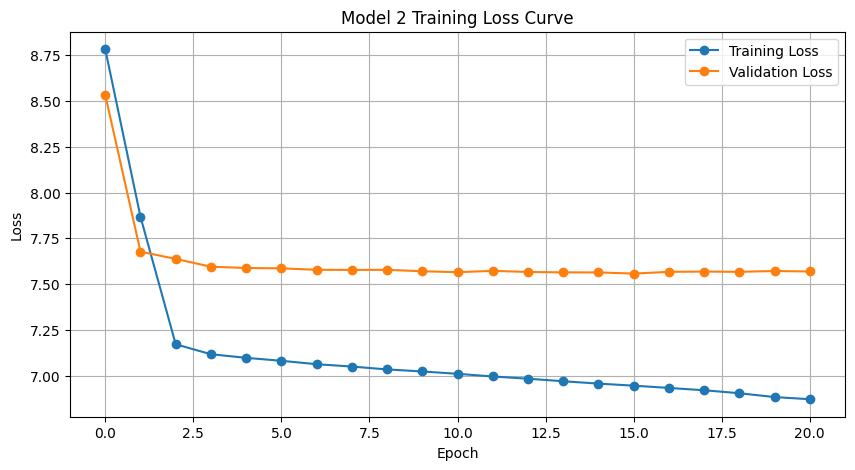

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(trainLosses, label="Training Loss", marker="o")
plt.plot(valLosses, label="Validation Loss", marker="o")
plt.title("Model 2 Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
import pandas as pd

# ================== Load Model 1 Checkpoint ==================
MODEL1_CHECKPOINT = Path("../../results/best_basic.pt")

model1Checkpoint = torch.load(MODEL1_CHECKPOINT, map_location=DEVICE)
model1TokenToIdx = model1Checkpoint["tokenToIdx"]
model1IdxToToken = {v: k for k, v in model1TokenToIdx.items()}


class BasicDecoder(nn.Module):
    """
    Basic LSTM decoder used for Model 1.
    Stores embedding and LSTM layers for greedy decoding.
    Provides forward() to decode one token step.
    """

    def __init__(self, vocabSize, embedDim, hiddenDim, numLayers, dropoutRate):
        """
        Initializes decoder layers.
        @param vocabSize Size of vocabulary.
        @param embedDim Embedding dimension.
        @param hiddenDim Hidden state dimension.
        @param numLayers Number of LSTM layers.
        @param dropoutRate Dropout probability.
        """
        super().__init__()
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedDim,
            hiddenDim,
            numLayers,
            batch_first=True,
            dropout=dropoutRate if numLayers > 1 else 0,
        )
        self.fc = nn.Linear(hiddenDim, vocabSize)
        self.dropout = nn.Dropout(dropoutRate)

    def forward(self, token, hiddenState):
        """
        Decodes one step of the sequence.
        @param token Current token ids with shape (batch,).
        @param hiddenState Previous LSTM hidden state tuple.
        @return Tuple of (logits, nextHiddenState).
        """
        embedded = self.dropout(self.embedding(token.unsqueeze(1)))
        output, nextHidden = self.lstm(embedded, hiddenState)
        logits = self.fc(output.squeeze(1))
        return logits, nextHidden


model1Encoder = Encoder(
    len(model1TokenToIdx),
    model1Checkpoint["embed_dim"],
    model1Checkpoint["hidden_dim"],
    model1Checkpoint["n_layers"],
    model1Checkpoint["dropout"],
).to(DEVICE)
model1Decoder = BasicDecoder(
    len(model1TokenToIdx),
    model1Checkpoint["embed_dim"],
    model1Checkpoint["hidden_dim"],
    model1Checkpoint["n_layers"],
    model1Checkpoint["dropout"],
).to(DEVICE)

model1Encoder.load_state_dict(
    {
        key.replace("encoder.", ""): value
        for key, value in model1Checkpoint["model_state"].items()
        if key.startswith("encoder.")
    }
)
model1Decoder.load_state_dict(
    {
        key.replace("decoder.", ""): value
        for key, value in model1Checkpoint["model_state"].items()
        if key.startswith("decoder.")
    }
)
model1Encoder.eval()
model1Decoder.eval()


@torch.no_grad()
def generateModel1Greedy(questionIds, maxLen=30):
    """
    Generates a greedy answer using Model 1.
    @param questionIds Token ids of the question.
    @param maxLen Maximum generated length.
    @return List of generated tokens.
    """
    src = torch.tensor([questionIds], device=DEVICE)
    srcLens = torch.tensor([len(questionIds)], device=DEVICE)

    _, hiddenState = model1Encoder(src, srcLens)
    token = torch.tensor([SOS_IDX], device=DEVICE)

    result = []
    for _ in range(maxLen):
        logits, hiddenState = model1Decoder(token, hiddenState)
        token = logits.argmax(dim=-1)
        if token.item() == EOS_IDX:
            break
        result.append(model1IdxToToken.get(token.item(), "<UNK>"))

    return result


@torch.no_grad()
def generateModel2Greedy(model, questionIds, maxLen=30):
    """
    Generates a greedy answer using Model 2.
    @param model Trained Model 2 Seq2Seq instance.
    @param questionIds Token ids of the question.
    @param maxLen Maximum generated length.
    @return List of generated tokens.
    """
    model.eval()
    src = torch.tensor([questionIds], device=DEVICE)
    srcLens = torch.tensor([len(questionIds)], device=DEVICE)

    encoderOutputs, hiddenState = model.encoder(src, srcLens)
    token = torch.tensor([SOS_IDX], device=DEVICE)

    result = []
    for _ in range(maxLen):
        logits, hiddenState = model.decoder(token, hiddenState, encoderOutputs)
        token = logits.argmax(dim=-1)
        if token.item() == EOS_IDX:
            break
        result.append(idxToToken.get(token.item(), "<UNK>"))

    return result


# ================== Model 2 Results ==================
model2Examples = samples

# ================== Calculate BLEU ==================
smoothie = SmoothingFunction().method4
data = []

for example in model2Examples[:6]:
    questionText = example["Question"]
    realAnswer = example["Real Answer"]

    questionTokens = questionText.split()
    questionIdsModel1 = (
        [SOS_IDX]
        + [model1TokenToIdx.get(t, UNK_IDX) for t in questionTokens]
        + [EOS_IDX]
    )
    questionIdsModel2 = (
        [SOS_IDX] + [tokenToIdx.get(t, UNK_IDX) for t in questionTokens] + [EOS_IDX]
    )

    model1PredTokens = generateModel1Greedy(questionIdsModel1)
    model2PredTokens = generateModel2Greedy(model2, questionIdsModel2)

    model1Pred = " ".join(model1PredTokens)
    model2Pred = " ".join(model2PredTokens)

    model1Bleu = sentence_bleu(
        [realAnswer.split()], model1Pred.split(), smoothing_function=smoothie
    )
    model2Bleu = sentence_bleu(
        [realAnswer.split()], model2Pred.split(), smoothing_function=smoothie
    )

    data.append(
        {
            "Question": questionText,
            "Real Answer": realAnswer,
            "Model 1 (No Attention)": model1Pred,
            "Model 2 (Luong Attention - Greedy)": model2Pred,
            "Model 1 BLEU": round(model1Bleu, 4),
            "Model 2 BLEU": round(model2Bleu, 4),
        }
    )

df = pd.DataFrame(data)
print("✅ Model 1 vs Model 2 Comparison Table (with BLEU)")
display(df)

# Optional: save to CSV for report
df.to_csv("../../results/model1_vs_model2_comparison.csv", index=False)
print("✅ Table saved as model1_vs_model2_comparison.csv")

✅ Model 1 vs Model 2 Comparison Table (with BLEU)


,Question,Real Answer,Model 1 (No Attention),Model 2 (Luong Attention - Greedy),Model 1 BLEU,Model 2 BLEU
0,how african americans were immigrated to the us,as such african immigrants are to be distingui...,the is is a is a of the of the of the of the o...,the is a is a is a of the of the of the and th...,0.0093,0.0104
1,how a water pump works,pumps operate by some mechanism typically reci...,the is is a is a of the of the of the of the,the is a is a of the of the of the and the and...,0.0115,0.0141
2,how old was sue lyon when she made lolita,the actress who played lolita sue lyon was fou...,the is is a is a of the of the of the of the o...,the is the is a is a of the of the of the of t...,0.0187,0.0197
3,what does s h i e l d stand for,the acronym originally stood for supreme headq...,the is is a is a is a of the of the of the of ...,the is the is a is a of the of the of the of t...,0.0142,0.0149
4,what day is st patricks day,saint patrick 's day or the feast of saint pat...,the is is a is a of the of the of the of the o...,the is a is a is a of the of the of the and the,0.0308,0.0301
5,how many books are included in the protestant ...,christian bibles range from the sixty six book...,the is is a is a of the of the of the of the o...,the is the is a is a of the of the of the of t...,0.0366,0.0357


✅ Table saved as model1_vs_model2_comparison.csv


---

## Results and interpretation

### What the numbers show

Validation loss improves quickly in the first few epochs then plateaus. The best checkpoint reached val loss 7.5576 (PPL ≈ 1915.33) at epoch 16; early stopping triggered at epoch 21 after 5 epochs without improvement. Training loss continued to fall to ~6.88 by epoch 20, widening the train–validation gap and indicating overfitting.

The average BLEU-1 from beam search evaluation is 0.0234 — slightly higher than previous runs but still very low, indicating little n‑gram overlap with reference answers.

### What the inference output shows

Generated answers remain dominated by high-frequency function words ("the", "is", "of"). Compared with Model 1, Model 2 yields occasional marginal BLEU gains on individual examples, but improvements are inconsistent.

### Why attention helps only marginally here

- Data scarcity: with fewer than 1k training pairs the model cannot learn reliable alignments.
- Exposure bias: teacher forcing during training creates a mismatch at inference.
- Search strategy is not a cure: beam search reduces repetition but cannot add missing content.

### Takeaway

Luong attention reduces the encoder bottleneck but does not materially alter behaviour on this small dataset. To make meaningful gains consider: more data, subword tokenization, pretraining/fine‑tuning, or retrieval‑augmented approaches.